# Session 30 – Improving the Model & Transfer Learning
**Topics:** data augmentation for imbalance · fine-tuning VGG16 / ResNet50 · feature extraction vs full fine-tuning · improving generalization · transfer learning for FER

| Task | What is done | Model |
|---|---|---|
| 1 | 3+ augmentations on 20 food images, 5 augmented versions of one image | `ImageDataGenerator` |
| 2 | Feature extraction on 30 sneaker images → `.npy` | VGG16 (`include_top=False`) |
| 3 | Glasses / no-glasses classifier, only last 20 layers retrained | ResNet50 |
| 4 | Feature extraction vs fine-tuning on T-shirt classes + written summary | ResNet50 |
| 5 | AI-generated code vs my adapted code, 3 headphone types | MobileNetV2 |

> **About the dataset.** The assignment asks for images of food, sneakers, selfies, T-shirts and headphones from a local directory.
> To make this notebook run end-to-end out of the box, the folder `dataset/` contains **procedurally generated (synthetic) images**
> created by `make_dataset.py` (random colours, rotation, lighting, noise). They are *not* real photographs.
> To use real photos, simply replace the images inside the same folders (keep the folder names) – **no code change is needed**.

## 0. Setup

In [1]:
import os, sys, random, subprocess, warnings
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

DATA = Path("dataset")           # input images
OUT = Path("outputs")            # everything this notebook saves
OUT.mkdir(exist_ok=True)
IMG_SIZE = (224, 224)

# if the dataset folder is missing, (re)generate the synthetic one
if not DATA.exists():
    subprocess.run([sys.executable, "make_dataset.py"], check=True)

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
for p in sorted(DATA.glob("*")):
    print(f"{p.name:14s}", sum(1 for _ in p.rglob('*.jpg')), "images")

I0000 00:00:1791118649.652826     478 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791118651.531906     478 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | Keras 3.15.1
food_images    20 images
glasses        70 images
headphones     120 images
sneakers       30 images
tshirts        120 images


In [2]:
# ---------- small helpers used by several tasks ----------
def merge_hist(*hists):
    # join the History objects of several .fit() calls into one dict
    out = {}
    for h in hists:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out


def plot_curves(h, title, split_at=None):
    # accuracy and loss curves; split_at = epoch where fine-tuning started
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ep = np.arange(1, len(h["loss"]) + 1)
    for a, key, name in zip(ax, ["accuracy", "loss"], ["Accuracy", "Loss"]):
        a.plot(ep, h[key], "o--", label="train")
        a.plot(ep, h["val_" + key], "o-", label="validation")
        if split_at:
            a.axvline(split_at + 0.5, color="gray", ls=":", label="unfreeze layers")
        a.set_xlabel("epoch"); a.set_ylabel(name); a.set_title(f"{title} - {name}")
        a.grid(alpha=.3); a.legend()
    plt.tight_layout(); plt.show()


def show_predictions(model, flow, n=8, binary=False, seed=SEED):
    flow.reset()
    probs = model.predict(flow, verbose=0)
    names = {v: k for k, v in flow.class_indices.items()}
    if binary:
        pred = (probs[:, 0] > 0.5).astype(int)
        conf = np.where(pred == 1, probs[:, 0], 1 - probs[:, 0])
    else:
        pred, conf = probs.argmax(1), probs.max(1)
    true = flow.classes
    idx = np.random.default_rng(seed).choice(len(true), size=min(n, len(true)), replace=False)
    cols = 4; rows = int(np.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.3 * rows))
    for a in np.ravel(axes): a.axis("off")
    for a, i in zip(np.ravel(axes), idx):
        a.imshow(load_img(flow.filepaths[i], target_size=IMG_SIZE))
        a.set_title(f"true: {names[true[i]]}\npred: {names[pred[i]]} ({conf[i]:.2f})",
                    color="green" if pred[i] == true[i] else "red", fontsize=9)
    plt.tight_layout(); plt.show()
    return pred, true, names


def report(true, pred, names):
    labels = sorted(names)
    tn = [names[i] for i in labels]
    print(classification_report(true, pred, target_names=tn, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(true, pred, labels=labels), display_labels=tn).plot(cmap="Blues", colorbar=False)
    plt.title("Validation confusion matrix"); plt.show()

---
## Task 1 – Data augmentation with `ImageDataGenerator`
**Goal:** apply at least three augmentations to 20 food images and display 5 augmented versions of one image.

Augmentations used (five kinds): **rotation**, **horizontal flip**, **zoom**, **width/height shift** and **brightness change**.
Augmentation creates new, slightly different training samples on the fly – it increases the effective dataset size, reduces overfitting and
is the standard way to give under-represented classes more variety (the "imbalance" idea from the session).

Found 20 images belonging to 1 classes.


originals: (20, 224, 224, 3)


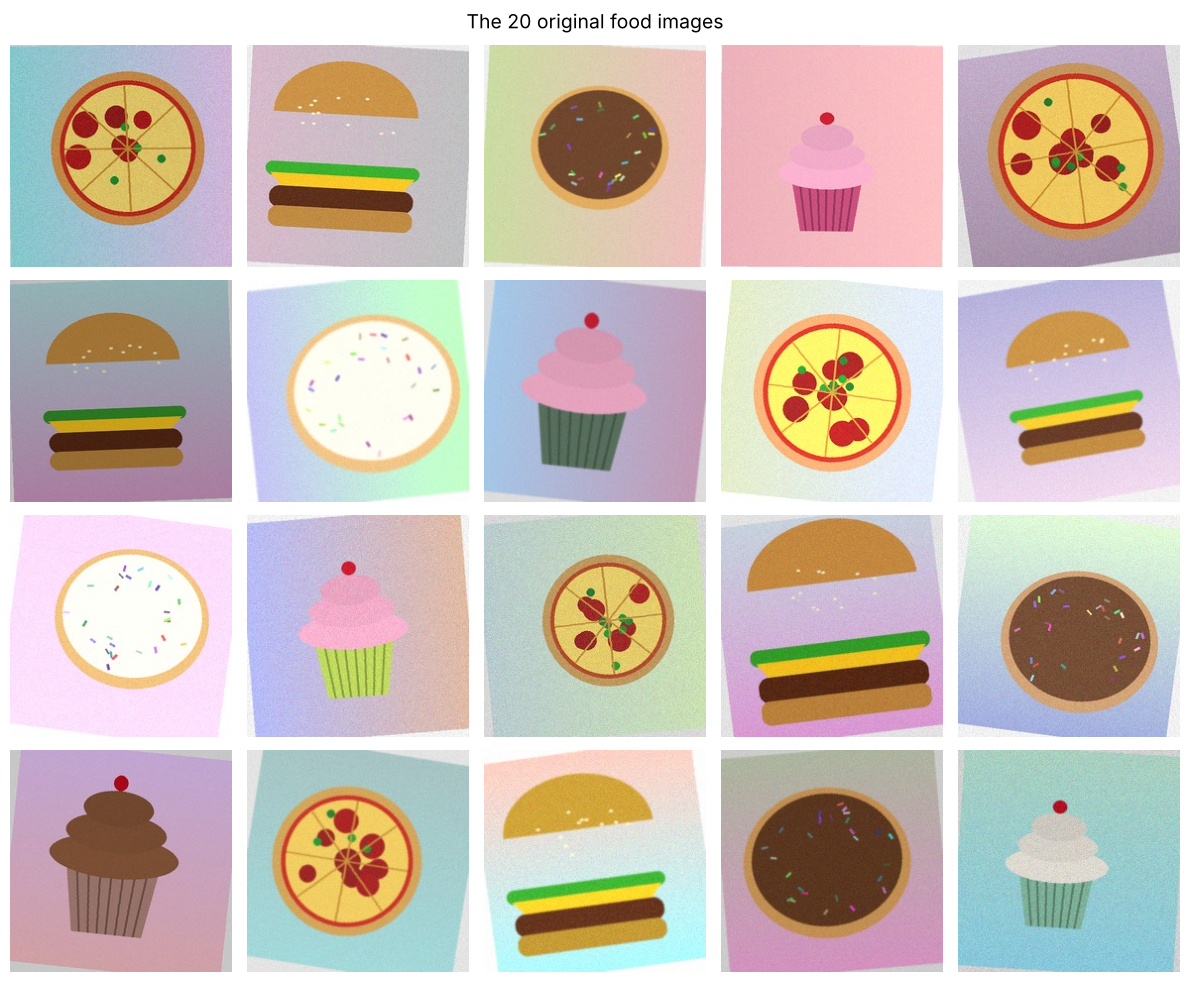

In [3]:
food_dir = DATA / "food_images"            # flow_from_directory needs  <root>/<class_folder>/*.jpg

datagen = ImageDataGenerator(
    rotation_range=40,              # 1) rotation  (+-40 degrees)
    horizontal_flip=True,           # 2) random left-right flip
    zoom_range=0.3,                 # 3) zoom in / out (70 % - 130 %)
    width_shift_range=0.15,         # 4) horizontal shift
    height_shift_range=0.15,        # 4) vertical shift
    brightness_range=(0.7, 1.3),    # 5) brightness
    fill_mode="nearest",
)

# 1) the 20 original images through flow_from_directory (no augmentation) -> grid
plain_flow = ImageDataGenerator().flow_from_directory(
    food_dir, target_size=IMG_SIZE, batch_size=20, class_mode=None, shuffle=False)
originals = next(plain_flow)                       # (20, 224, 224, 3), values 0-255
print("originals:", originals.shape)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for a, im in zip(axes.ravel(), originals):
    a.imshow(im.astype("uint8")); a.axis("off")
plt.suptitle("The 20 original food images", fontsize=14); plt.tight_layout(); plt.show()

Found 20 images belonging to 1 classes.


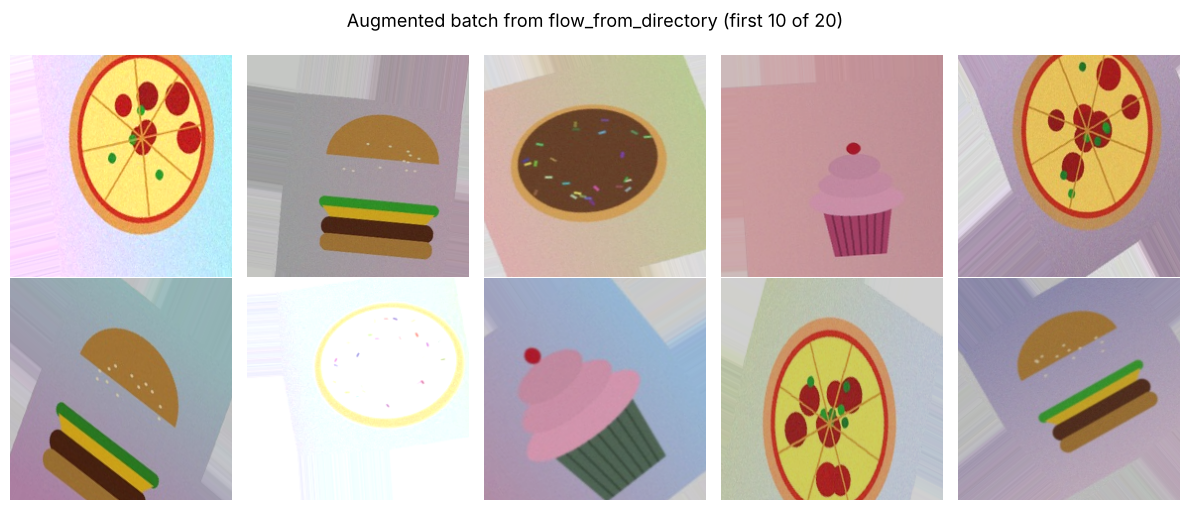

In [4]:
# 2) one augmented batch straight from flow_from_directory (the same 20 images, now randomly transformed)
aug_flow = datagen.flow_from_directory(
    food_dir, target_size=IMG_SIZE, batch_size=20, class_mode=None, shuffle=False, seed=SEED)
aug_batch = next(aug_flow)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
for a, im in zip(axes.ravel(), aug_batch[:10]):
    a.imshow(np.clip(im, 0, 255).astype("uint8")); a.axis("off")
plt.suptitle("Augmented batch from flow_from_directory (first 10 of 20)", fontsize=13); plt.tight_layout(); plt.show()

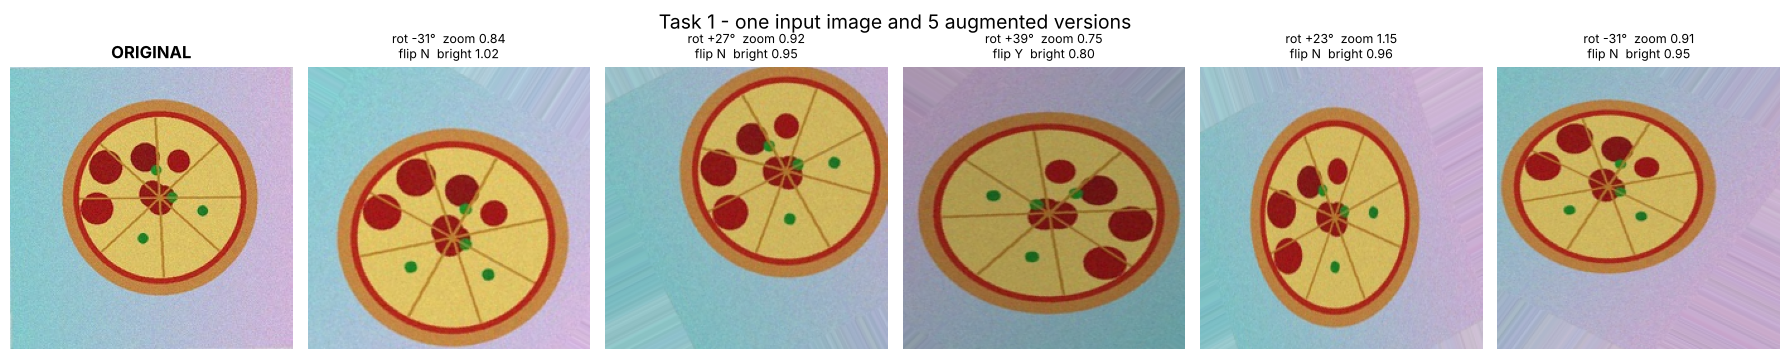

In [5]:
# 3) ONE input image -> 5 augmented versions, titled with the random transformation that was applied
IDX = 0                                            # a pizza
x = originals[IDX]
rng_state = np.random.RandomState(SEED)

fig, axes = plt.subplots(1, 6, figsize=(18, 3.6))
axes[0].imshow(x.astype("uint8")); axes[0].set_title("ORIGINAL", fontweight="bold"); axes[0].axis("off")
for i in range(1, 6):
    params = datagen.get_random_transform(x.shape, seed=SEED + i)
    x_aug = datagen.apply_transform(x, params)
    b = params.get("brightness")
    axes[i].imshow(np.clip(x_aug, 0, 255).astype("uint8")); axes[i].axis("off")
    axes[i].set_title(f"rot {params['theta']:+.0f}°  zoom {params['zx']:.2f}\n"
                      f"flip {'Y' if params.get('flip_horizontal') else 'N'}  bright {b if b else 1:.2f}", fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.suptitle("Task 1 - one input image and 5 augmented versions", fontsize=14, y=0.99)
plt.savefig(OUT / "task1_augmentations.png", dpi=130, bbox_inches="tight")
plt.show()

---
## Task 2 – Feature extraction with VGG16
**Goal:** load VGG16 (ImageNet weights, `include_top=False`), extract features from 30 sneaker images and save them as `.npy`.

With `include_top=False` the fully-connected classifier is removed, so the network ends at the last convolution/pooling block and returns a
**7 × 7 × 512 feature map** per image – a compact, general description of what is in the picture.

In [6]:
sneaker_dir = DATA / "sneakers" / "sneaker"
files = sorted(sneaker_dir.glob("*.jpg"))[:30]
assert len(files) == 30, f"expected 30 images, found {len(files)}"

# load -> array -> VGG16 preprocessing (RGB->BGR + ImageNet mean subtraction)
X = np.stack([img_to_array(load_img(f, target_size=IMG_SIZE)) for f in files])
print("input batch:", X.shape)
X_in = vgg_pre(X.copy())

vgg = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
print("VGG16 layers:", len(vgg.layers), "| output shape per image:", vgg.output_shape[1:])

features = vgg.predict(X_in, batch_size=10, verbose=0)
print("extracted features:", features.shape, features.dtype)

np.save(OUT / "sneaker_features_vgg16.npy", features)                       # raw 7x7x512 maps
np.save(OUT / "sneaker_features_vgg16_pooled.npy", features.mean(axis=(1, 2)))   # 512-d vector / image

# verify the saved file
loaded = np.load(OUT / "sneaker_features_vgg16.npy")
assert loaded.shape == (30, 7, 7, 512) and np.allclose(loaded, features)
print("saved ->", OUT / "sneaker_features_vgg16.npy", f"({(OUT / 'sneaker_features_vgg16.npy').stat().st_size / 1e6:.1f} MB), reloaded OK")

input batch: (30, 224, 224, 3)


VGG16 layers: 19 | output shape per image: (7, 7, 512)


extracted features: (30, 7, 7, 512) float32
saved -> outputs/sneaker_features_vgg16.npy (3.0 MB), reloaded OK


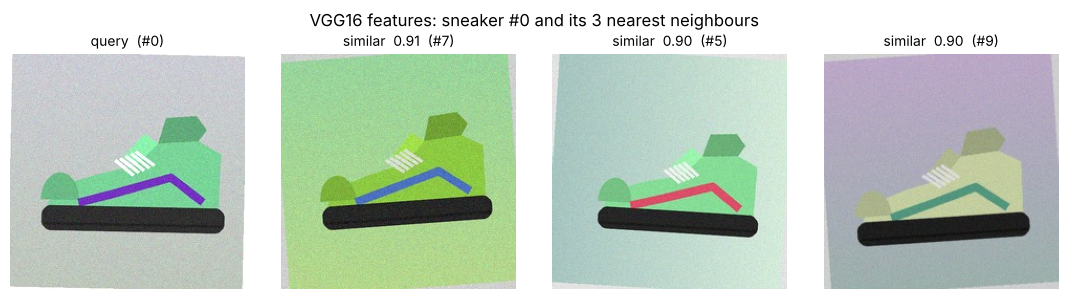

In [7]:
# quick sanity check that the features are meaningful: nearest neighbours of sneaker #0 by cosine similarity
pooled = np.load(OUT / "sneaker_features_vgg16_pooled.npy")
unit = pooled / np.linalg.norm(pooled, axis=1, keepdims=True)
sim = unit @ unit[0]
nearest = np.argsort(-sim)[:4]            # itself + 3 most similar

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for a, i in zip(axes, nearest):
    a.imshow(X[i].astype("uint8")); a.axis("off")
    a.set_title(("query" if i == 0 else f"similar  {sim[i]:.2f}") + f"  (#{i})", fontsize=10)
plt.suptitle("VGG16 features: sneaker #0 and its 3 nearest neighbours", fontsize=12); plt.tight_layout(); plt.show()

---
## Task 3 – Fine-tune ResNet50 (selfie: glasses / no glasses)
**Constraint:** only the **last 20 layers** are retrained, all earlier layers stay frozen.

Dataset: 25 + 10 images per class = **70 selfie-style images** (≥ 40 required), split into `train` (50) and `val` (20).

Training is done in two steps, the standard recipe:
1. **Warm-up** – whole ResNet50 frozen, only the new classifier head is trained (so random head weights don't wreck the pretrained layers).
2. **Fine-tuning** – unfreeze the last 20 layers of ResNet50 and continue with a small learning rate.

In [8]:
glass_dir = DATA / "glasses"

train_gen = ImageDataGenerator(preprocessing_function=resnet_pre, rotation_range=15, zoom_range=0.15,
                               width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True,
                               brightness_range=(0.8, 1.2))
val_gen = ImageDataGenerator(preprocessing_function=resnet_pre)

train_flow = train_gen.flow_from_directory(glass_dir / "train", target_size=IMG_SIZE, batch_size=8,
                                           class_mode="binary", seed=SEED)
val_flow = val_gen.flow_from_directory(glass_dir / "val", target_size=IMG_SIZE, batch_size=8,
                                       class_mode="binary", shuffle=False)
print("class mapping:", train_flow.class_indices, "| total images:", train_flow.samples + val_flow.samples)

Found 50 images belonging to 2 classes.


Found 20 images belonging to 2 classes.


class mapping: {'glasses': 0, 'no_glasses': 1} | total images: 70


In [9]:
tf.keras.utils.set_random_seed(SEED)

base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False                                   # step 1: everything frozen

inputs = keras.Input((224, 224, 3))
x = base(inputs, training=False)                         # training=False keeps BatchNorm statistics fixed
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)       # glasses vs no_glasses
model = keras.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
WARM = 5
h_warm = model.fit(train_flow, validation_data=val_flow, epochs=WARM, verbose=2)

Epoch 1/5


7/7 - 10s - 1s/step - accuracy: 0.5000 - loss: 0.7872 - val_accuracy: 0.7000 - val_loss: 0.5749


Epoch 2/5


7/7 - 3s - 455ms/step - accuracy: 0.7400 - loss: 0.5544 - val_accuracy: 0.8000 - val_loss: 0.4596


Epoch 3/5


7/7 - 5s - 722ms/step - accuracy: 0.8200 - loss: 0.4305 - val_accuracy: 0.9500 - val_loss: 0.3603


Epoch 4/5


7/7 - 5s - 714ms/step - accuracy: 0.8800 - loss: 0.2975 - val_accuracy: 0.9500 - val_loss: 0.2759


Epoch 5/5


7/7 - 4s - 504ms/step - accuracy: 0.9800 - loss: 0.2455 - val_accuracy: 0.9500 - val_loss: 0.2478


In [10]:
# ---- step 2 : unfreeze ONLY the last 20 layers of ResNet50 ----
N_UNFREEZE = 20
base.trainable = True
for layer in base.layers[:-N_UNFREEZE]:
    layer.trainable = False

# --- verify the constraint ---
trainable_layers = [l.name for l in base.layers if l.trainable]
print(f"ResNet50 layers: {len(base.layers)} | trainable: {len(trainable_layers)} | frozen: {len(base.layers) - len(trainable_layers)}")
assert len(trainable_layers) == N_UNFREEZE
assert all(not l.trainable for l in base.layers[:-N_UNFREEZE])
print("trainable layers:", trainable_layers)
n_tr = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
n_all = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"trainable parameters: {n_tr:,} of {n_all:,}")

model.compile(optimizer=optimizers.Adam(5e-5), loss="binary_crossentropy", metrics=["accuracy"])   # re-compile after changing trainable
FT = 10
h_ft = model.fit(train_flow, validation_data=val_flow, epochs=FT, verbose=2)

ResNet50 layers: 175 | trainable: 20 | frozen: 155
trainable layers: ['conv5_block2_1_conv', 'conv5_block2_1_bn', 'conv5_block2_1_relu', 'conv5_block2_2_conv', 'conv5_block2_2_bn', 'conv5_block2_2_relu', 'conv5_block2_3_conv', 'conv5_block2_3_bn', 'conv5_block2_add', 'conv5_block2_out', 'conv5_block3_1_conv', 'conv5_block3_1_bn', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_3_bn', 'conv5_block3_add', 'conv5_block3_out']
trainable parameters: 8,933,377 of 23,589,761
Epoch 1/10


7/7 - 12s - 2s/step - accuracy: 0.8800 - loss: 0.2877 - val_accuracy: 0.9000 - val_loss: 0.1792


Epoch 2/10


7/7 - 9s - 1s/step - accuracy: 1.0000 - loss: 0.0746 - val_accuracy: 0.9000 - val_loss: 0.2794


Epoch 3/10


...

7/7 - 5s - 773ms/step - accuracy: 1.0000 - loss: 0.0266 - val_accuracy: 0.9000 - val_loss: 0.4603


Epoch 9/10


7/7 - 4s - 536ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9000 - val_loss: 0.3617


Epoch 10/10


7/7 - 4s - 530ms/step - accuracy: 0.9800 - loss: 0.0517 - val_accuracy: 0.9000 - val_loss: 0.3354


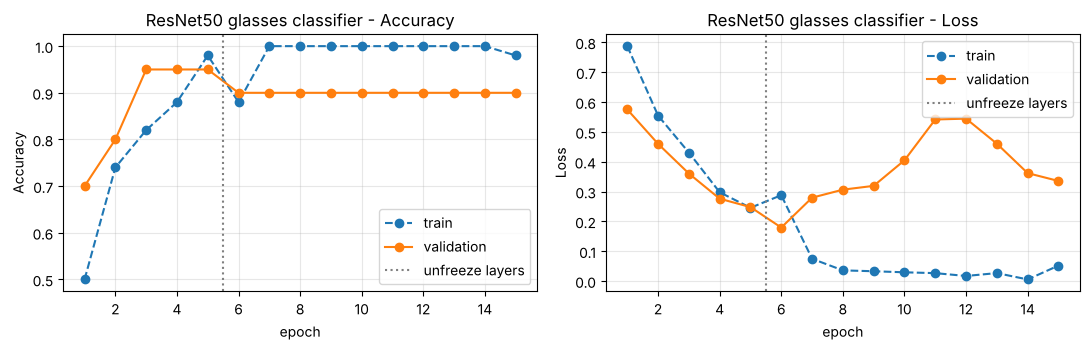

Final validation accuracy: 0.900   (loss 0.335)   |   final train accuracy: 0.980


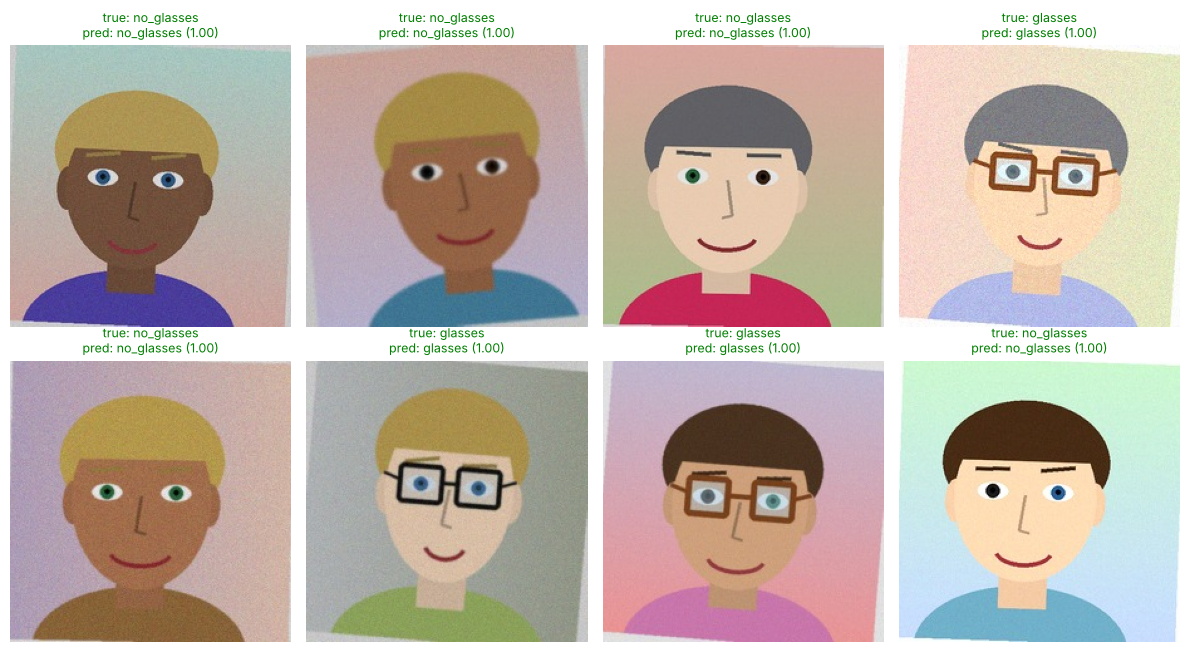

              precision    recall  f1-score   support

     glasses      1.000     0.800     0.889        10
  no_glasses      0.833     1.000     0.909        10

    accuracy                          0.900        20
   macro avg      0.917     0.900     0.899        20
weighted avg      0.917     0.900     0.899        20



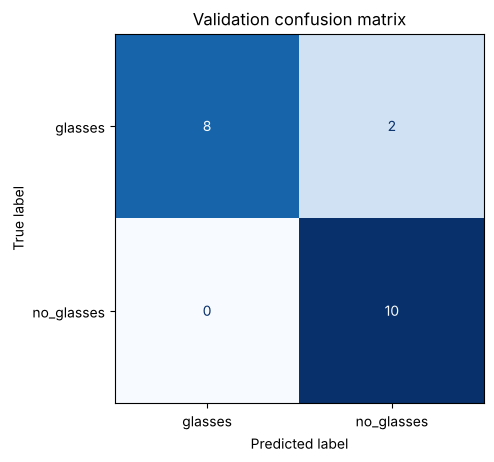

In [11]:
hist3 = merge_hist(h_warm, h_ft)
plot_curves(hist3, "ResNet50 glasses classifier", split_at=WARM)

val_loss, val_acc = model.evaluate(val_flow, verbose=0)
print(f"Final validation accuracy: {val_acc:.3f}   (loss {val_loss:.3f})   |   final train accuracy: {hist3['accuracy'][-1]:.3f}")

pred, true, names = show_predictions(model, val_flow, n=8, binary=True)
report(true, pred, names)

**Observation (Task 3).** The warm-up alone (ResNet50 fully frozen) already reached 95 % validation accuracy. After unfreezing the last 20 layers the training accuracy went to ~100 % while validation accuracy settled at 90 % (2 of the 20 validation images wrong – both *glasses* images predicted as *no_glasses*), and the validation loss rose from 0.18 to about 0.54 before dropping back to 0.34. That is a sign of mild overfitting with only 50 training images; because one validation image is worth 5 %, the 95 % vs 90 % difference is within noise. More augmentation, early stopping or more data would be the next steps.

---
## Task 4 – Feature extraction vs fine-tuning (T-shirts, 3 classes)
Dataset: **plain / striped / printed** T-shirts, 30 train + 10 val images per class (90 / 30).
Both approaches use the same ResNet50, same data, same augmentation, same seed and the same **12 epochs**:

| | Phase 1 (epochs 1-4) | Phase 2 (epochs 5-12) |
|---|---|---|
| **A. Feature extraction** | base frozen, train head, lr 1e-3 | base still frozen, lr 1e-3 |
| **B. Fine-tuning** | base frozen, train head, lr 1e-3 | **last 30 layers unfrozen**, lr 1e-4 |

In [12]:
shirt_dir = DATA / "tshirts"
EPOCHS, WARMUP, N_UNFREEZE_4 = 12, 4, 30


def make_flows(batch=16):
    tr = ImageDataGenerator(preprocessing_function=resnet_pre, rotation_range=15, zoom_range=0.15,
                            width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
    va = ImageDataGenerator(preprocessing_function=resnet_pre)
    return (tr.flow_from_directory(shirt_dir / "train", target_size=IMG_SIZE, batch_size=batch,
                                   class_mode="categorical", seed=SEED),
            va.flow_from_directory(shirt_dir / "val", target_size=IMG_SIZE, batch_size=batch,
                                   class_mode="categorical", shuffle=False))


def build_classifier(n_classes):
    b = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    b.trainable = False
    inp = keras.Input((224, 224, 3))
    h = b(inp, training=False)
    h = layers.GlobalAveragePooling2D()(h)
    h = layers.Dropout(0.3)(h)
    out = layers.Dense(n_classes, activation="softmax")(h)
    return keras.Model(inp, out), b


def compile_model(m, lr):
    m.compile(optimizer=optimizers.Adam(lr), loss="categorical_crossentropy", metrics=["accuracy"])

In [13]:
# ---------- A. feature extraction : the whole ResNet50 stays frozen ----------
tf.keras.utils.set_random_seed(SEED)
train_flow4, val_flow4 = make_flows()
n_classes = train_flow4.num_classes
print("classes:", train_flow4.class_indices)

model_fe, base_fe = build_classifier(n_classes)
compile_model(model_fe, 1e-3)
print("A) trainable layers in base:", sum(l.trainable for l in base_fe.layers), "(all frozen)")
h_fe = model_fe.fit(train_flow4, validation_data=val_flow4, epochs=EPOCHS, verbose=2)

Found 90 images belonging to 3 classes.


Found 30 images belonging to 3 classes.


classes: {'plain': 0, 'printed': 1, 'striped': 2}


A) trainable layers in base: 0 (all frozen)


Epoch 1/12


...

6/6 - 5s - 867ms/step - accuracy: 0.8222 - loss: 0.4078 - val_accuracy: 0.8667 - val_loss: 0.3963


Epoch 11/12


6/6 - 6s - 922ms/step - accuracy: 0.9000 - loss: 0.3408 - val_accuracy: 0.9000 - val_loss: 0.3904


Epoch 12/12


6/6 - 5s - 858ms/step - accuracy: 0.7889 - loss: 0.4711 - val_accuracy: 0.8667 - val_loss: 0.4280


In [14]:
# ---------- B. fine-tuning : unfreeze the last 30 layers after a 4-epoch warm-up ----------
tf.keras.utils.set_random_seed(SEED)
train_flow4, val_flow4 = make_flows()

model_ft, base_ft = build_classifier(n_classes)
compile_model(model_ft, 1e-3)
h_ft1 = model_ft.fit(train_flow4, validation_data=val_flow4, epochs=WARMUP, verbose=2)

base_ft.trainable = True
for l in base_ft.layers[:-N_UNFREEZE_4]:
    l.trainable = False
print("B) trainable layers in base:", sum(l.trainable for l in base_ft.layers), "of", len(base_ft.layers))
assert sum(l.trainable for l in base_ft.layers) == N_UNFREEZE_4
compile_model(model_ft, 1e-4)
h_ft2 = model_ft.fit(train_flow4, validation_data=val_flow4, epochs=EPOCHS - WARMUP, verbose=2)
h_ft_all = merge_hist(h_ft1, h_ft2)

Found 90 images belonging to 3 classes.


Found 30 images belonging to 3 classes.


Epoch 1/4


6/6 - 11s - 2s/step - accuracy: 0.2778 - loss: 1.5625 - val_accuracy: 0.5000 - val_loss: 1.0681


Epoch 2/4


...

6/6 - 10s - 2s/step - accuracy: 0.9778 - loss: 0.0360 - val_accuracy: 0.7667 - val_loss: 0.7157


Epoch 7/8


6/6 - 7s - 1s/step - accuracy: 0.9889 - loss: 0.0214 - val_accuracy: 0.9333 - val_loss: 0.3278


Epoch 8/8


6/6 - 12s - 2s/step - accuracy: 1.0000 - loss: 0.0142 - val_accuracy: 0.9333 - val_loss: 0.2108


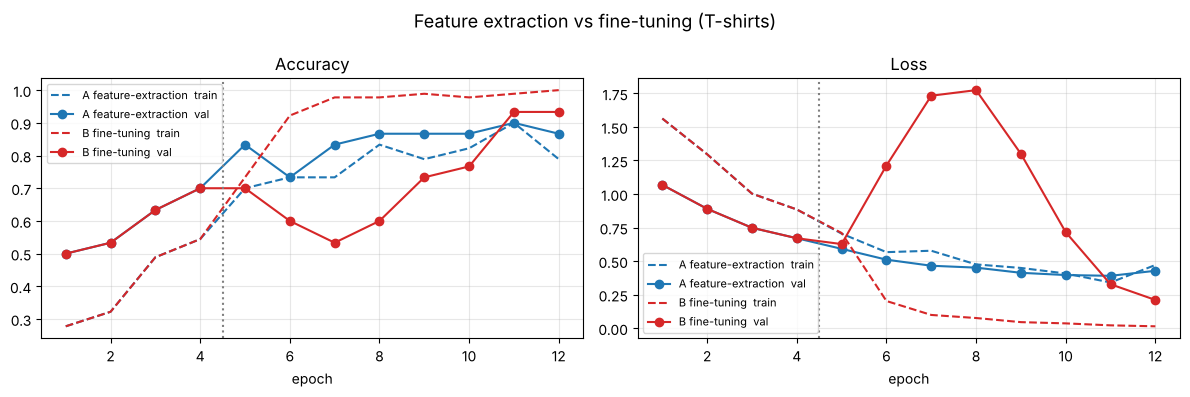

Approach,A. Feature extraction (all frozen),B. Fine-tuning (last 30 layers)
Final train acc,0.789,1.000
Final val acc,0.867,0.933
Best val acc,0.900,0.933
Train-val acc gap (avg last 3 ep),-0.041,0.111
Min val loss,0.390,0.211
Final val loss,0.428,0.211
Val-loss rise after its min,0.038,0.000


In [15]:
h_fe_d = h_fe.history

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = np.arange(1, EPOCHS + 1)
for a, key, nm in zip(ax, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    a.plot(ep, h_fe_d[key], "--", color="tab:blue", label="A feature-extraction  train")
    a.plot(ep, h_fe_d["val_" + key], "-o", color="tab:blue", label="A feature-extraction  val")
    a.plot(ep, h_ft_all[key], "--", color="tab:red", label="B fine-tuning  train")
    a.plot(ep, h_ft_all["val_" + key], "-o", color="tab:red", label="B fine-tuning  val")
    a.axvline(WARMUP + .5, color="gray", ls=":")
    a.set_title(nm); a.set_xlabel("epoch"); a.grid(alpha=.3); a.legend(fontsize=8)
plt.suptitle("Feature extraction vs fine-tuning (T-shirts)", fontsize=13); plt.tight_layout()
plt.savefig(OUT / "task4_comparison.png", dpi=130, bbox_inches="tight"); plt.show()


def summarise(h, name):
    acc, vacc, vl = np.array(h["accuracy"]), np.array(h["val_accuracy"]), np.array(h["val_loss"])
    return {"Approach": name,
            "Final train acc": acc[-1], "Final val acc": vacc[-1], "Best val acc": vacc.max(),
            "Train-val acc gap (avg last 3 ep)": (acc[-3:] - vacc[-3:]).mean(),
            "Min val loss": vl.min(), "Final val loss": vl[-1],
            "Val-loss rise after its min": vl[-1] - vl.min()}


summary = pd.DataFrame([summarise(h_fe_d, "A. Feature extraction (all frozen)"),
                        summarise(h_ft_all, "B. Fine-tuning (last 30 layers)")]).set_index("Approach")
summary.round(3).T

In [16]:
# val accuracy of the final models, per class, on the 30 validation images
for nm, m in [("A. Feature extraction", model_fe), ("B. Fine-tuning", model_ft)]:
    print("=" * 60, "\n", nm)
    p = m.predict(val_flow4, verbose=0).argmax(1)
    print(classification_report(val_flow4.classes, p, target_names=list(val_flow4.class_indices), digits=3))

 A. Feature extraction


              precision    recall  f1-score   support

       plain      1.000     0.900     0.947        10
     printed      0.714     1.000     0.833        10
     striped      1.000     0.700     0.824        10

    accuracy                          0.867        30
   macro avg      0.905     0.867     0.868        30
weighted avg      0.905     0.867     0.868        30

 B. Fine-tuning


              precision    recall  f1-score   support

       plain      1.000     0.900     0.947        10
     printed      0.833     1.000     0.909        10
     striped      1.000     0.900     0.947        10

    accuracy                          0.933        30
   macro avg      0.944     0.933     0.935        30
weighted avg      0.944     0.933     0.935        30



### Summary – which approach generalized better and why?
**Fine-tuning generalized better in this experiment.** It reached 93.3 % validation accuracy (28/30 images, val-loss 0.21) versus 86.7 % (26/30, val-loss 0.43) for feature extraction, mainly because it recognised *striped* shirts much better (recall 0.9 vs 0.7). The reason is that the earlier ResNet50 layers hold generic edges/textures, but the last blocks are specialised for ImageNet objects; unfreezing them lets the network learn shirt-specific patterns (stripes vs. prints), while a frozen backbone can only re-weight fixed features. The price is a higher overfitting tendency: fine-tuning hit 100 % training accuracy (train–val gap ≈ +0.11) and right after unfreezing its validation loss spiked to 1.77 (accuracy fell to 53 %) before recovering, whereas feature extraction was smooth and stable (it was actually still under-fitting, 79 % train accuracy, so its negative gap just reflects dropout + augmentation). So fine-tuning = higher accuracy but less stable; feature extraction = safer and cheaper when data is very small.

*Caveat: only 30 validation images (one image = 3.3 %) and a single run, so a 2-image difference is suggestive, not conclusive.*

---
## Task 5 – AI-generated code → adapted code (MobileNetV2, 3 headphone types)

**Prompt given to the AI assistant:**
> *"Write a Keras code snippet for transfer learning with MobileNetV2 for classifying 3 types of headphones."*

> **Note on the tool:** the assignment mentions ChatGPT / Copilot. The snippet below was generated with **Claude** (Anthropic's AI assistant) instead.
> Any AI assistant can be used here – if your instructor needs the output of a specific tool, paste its snippet in this cell and compare in the same way.

### 5a. AI-generated code (as received, not modified)
```python
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
val_dir = "data/val"

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(train_dir, target_size=(224, 224),
                                        batch_size=32, class_mode="categorical")
val_gen = datagen.flow_from_directory(val_dir, target_size=(224, 224),
                                      batch_size=32, class_mode="categorical")

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(train_gen, validation_data=val_gen, epochs=10)
```

### 5b. What I changed and why
| # | Change | Reason |
|---|---|---|
| 1 | Paths → `dataset/headphones/train` and `/val` (classes: `over_ear`, `earbuds`, `neckband`) | use my own dataset |
| 2 | `rescale=1./255` → MobileNetV2's own `preprocess_input` | MobileNetV2 was trained on inputs scaled to **[-1, 1]**, not [0, 1] – wrong scaling lowers accuracy |
| 3 | Added augmentation (rotation, zoom, shift, flip, brightness) on the train set only | small dataset → less overfitting |
| 4 | Batch size 32 → 16 | only 90 training images; more update steps per epoch |
| 5 | Functional API + `base_model(x, training=False)` | keeps BatchNorm layers in inference mode (important when fine-tuning) |
| 6 | Dense(128)+Dropout(0.5) → Dropout(0.2) + Dense(3) | simpler head is enough on top of 1280 strong features |
| 7 | Added `EarlyStopping` + `ReduceLROnPlateau` | stop when validation stops improving |
| 8 | Added a short fine-tuning phase (top 30 layers, lr 1e-5) | extra generalization (session topic) |
| 9 | Added evaluation: classification report, confusion matrix, sample predictions, model saving | the original code only trained |

### 5c. My adapted code (executed)

In [17]:
hp_dir = DATA / "headphones"

train_gen5 = ImageDataGenerator(preprocessing_function=mobilenet_pre,          # change 2
                                rotation_range=15, zoom_range=0.15,            # change 3
                                width_shift_range=0.1, height_shift_range=0.1,
                                horizontal_flip=True, brightness_range=(0.8, 1.2))
val_gen5 = ImageDataGenerator(preprocessing_function=mobilenet_pre)

train_flow5 = train_gen5.flow_from_directory(hp_dir / "train", target_size=IMG_SIZE, batch_size=16,   # changes 1, 4
                                             class_mode="categorical", seed=SEED)
val_flow5 = val_gen5.flow_from_directory(hp_dir / "val", target_size=IMG_SIZE, batch_size=16,
                                         class_mode="categorical", shuffle=False)
print(train_flow5.class_indices)

tf.keras.utils.set_random_seed(SEED)
base5 = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base5.trainable = False

inp = keras.Input((224, 224, 3))
x = base5(inp, training=False)                                  # change 5
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)                                      # change 6
out = layers.Dense(3, activation="softmax")(x)
model5 = keras.Model(inp, out)

cbs = [callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),     # change 7
       callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)]

# phase 1 : train the head
model5.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
h5a = model5.fit(train_flow5, validation_data=val_flow5, epochs=10, callbacks=cbs, verbose=2)

Found 90 images belonging to 3 classes.


Found 30 images belonging to 3 classes.


{'earbuds': 0, 'neckband': 1, 'over_ear': 2}


Epoch 1/10


6/6 - 6s - 961ms/step - accuracy: 0.5111 - loss: 1.0220 - val_accuracy: 0.9333 - val_loss: 0.4530 - learning_rate: 0.0010


...

6/6 - 2s - 366ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0078 - learning_rate: 0.0010


Epoch 9/10


6/6 - 2s - 329ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0070 - learning_rate: 0.0010


Epoch 10/10


6/6 - 2s - 343ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 0.0063 - learning_rate: 0.0010


In [18]:
# phase 2 : fine-tune the top 30 layers of MobileNetV2 with a very small learning rate     (change 8)
base5.trainable = True
for l in base5.layers[:-30]:
    l.trainable = False
print("trainable layers:", sum(l.trainable for l in base5.layers), "of", len(base5.layers))

model5.compile(optimizer=optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
h5b = model5.fit(train_flow5, validation_data=val_flow5, epochs=8, callbacks=cbs, verbose=2)

trainable layers: 30 of 154


Epoch 1/8


6/6 - 9s - 2s/step - accuracy: 0.9778 - loss: 0.1606 - val_accuracy: 1.0000 - val_loss: 0.0047 - learning_rate: 1.0000e-05


Epoch 2/8


6/6 - 2s - 382ms/step - accuracy: 0.9889 - loss: 0.1441 - val_accuracy: 1.0000 - val_loss: 0.0036 - learning_rate: 1.0000e-05


...

6/6 - 3s - 445ms/step - accuracy: 1.0000 - loss: 0.0394 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 1.0000e-05


Epoch 7/8


6/6 - 3s - 422ms/step - accuracy: 1.0000 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 1.0000e-05


Epoch 8/8


6/6 - 2s - 397ms/step - accuracy: 0.9667 - loss: 0.0814 - val_accuracy: 1.0000 - val_loss: 0.0011 - learning_rate: 1.0000e-05


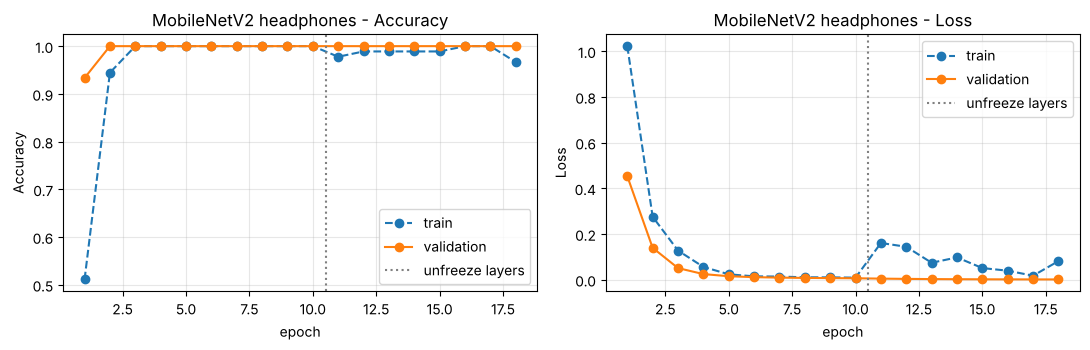

Validation accuracy: 1.000 | loss: 0.001


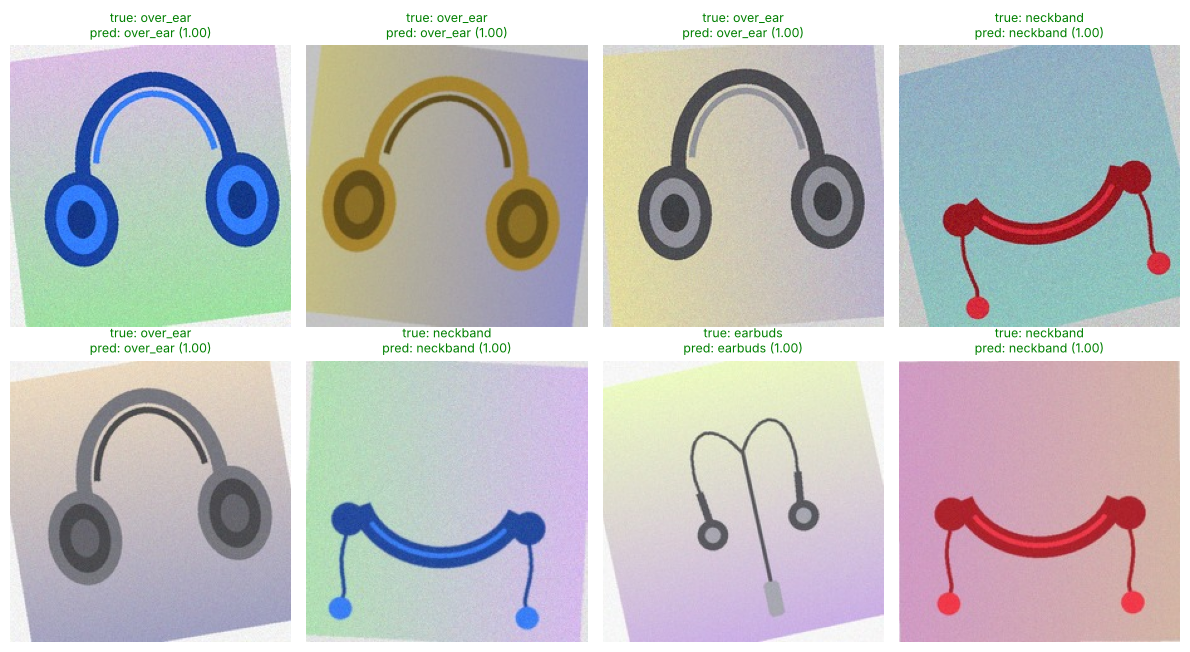

              precision    recall  f1-score   support

     earbuds      1.000     1.000     1.000        10
    neckband      1.000     1.000     1.000        10
    over_ear      1.000     1.000     1.000        10

    accuracy                          1.000        30
   macro avg      1.000     1.000     1.000        30
weighted avg      1.000     1.000     1.000        30



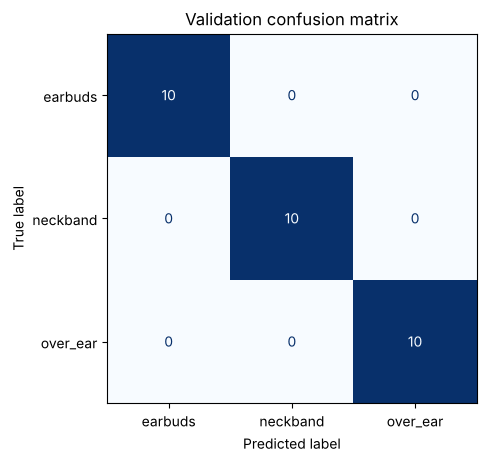

model saved -> outputs/headphones_mobilenetv2.keras


In [19]:
hist5 = merge_hist(h5a, h5b)
plot_curves(hist5, "MobileNetV2 headphones", split_at=len(h5a.history["loss"]))

loss5, acc5 = model5.evaluate(val_flow5, verbose=0)
print(f"Validation accuracy: {acc5:.3f} | loss: {loss5:.3f}")

pred5, true5, names5 = show_predictions(model5, val_flow5, n=8)
report(true5, pred5, names5)

model5.save(OUT / "headphones_mobilenetv2.keras")             # change 9
print("model saved ->", OUT / "headphones_mobilenetv2.keras")

---
## Overall summary
* **Task 1** – five augmentation types (rotation, flip, zoom, shift, brightness) shown on 20 food images and 5 variants of one image.
* **Task 2** – VGG16 (`include_top=False`) turned 30 sneaker images into `(30, 7, 7, 512)` features, saved in `outputs/sneaker_features_vgg16.npy`.
* **Task 3** – ResNet50 fine-tuned for glasses / no-glasses with exactly the **last 20 layers trainable** (verified with an `assert`).
* **Task 4** – feature extraction vs fine-tuning compared with accuracy, loss and train–validation gap (written summary above).
* **Task 5** – AI-generated MobileNetV2 snippet, the list of my modifications, and the adapted version trained on the headphone dataset.

*Remember: the bundled images are synthetic; with real photos accuracy will be lower and the effect of fine-tuning/augmentation usually larger.*